In [1]:
import numpy as np 
import pandas as pd
import pickle
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path 
import re 
# get utils for thresholds
from src import util_analysis 
from src import util_process_prolific as util_process

from tqdm.auto import tqdm
import multiprocessing as mp
from scipy.stats import norm
from scipy.special import ndtri
from pathlib import Path, PosixPath

/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/scipy/__init__.py:138: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion} is required for this version of "


## Load participant data and meta files 

In [2]:
### Load in experiment manifests with full transcripts
path_to_manifest = Path('/om/user/imgriff/datasets/human_word_rec_SWC_2024/full_cue_target_distractor_df_w_meta_transcripts.pdpkl')
df_w_transcripts = pd.read_pickle(path_to_manifest)
df_w_transcripts['targ_src_stem'] = df_w_transcripts.excerpt_src_fn.apply(util_process.slice_transcript_path)

def get_sex_cond(tgt_name, df_w_transcripts=df_w_transcripts):
    if tgt_name is None:
        return None
    return df_w_transcripts[df_w_transcripts["targ_src_stem"] == tgt_name].sex_cond.item()



In [3]:
path_to_parts = Path('/mindhive/mcdermott/www/imgriff/part_data/binaural_cocktail_party/localize_speech_in_elevation_w_distractor_v00/')
part_results = sorted(list(path_to_parts.glob("part*")))

path_to_meta_data = Path('/mindhive/mcdermott/www/imgriff/part_data/binaural_cocktail_party/speaker_array_manifests/localize_speech_in_elevation_w_distractor_v00/')
meta_files = sorted(list(path_to_meta_data.glob("*meta.pkl")))
array_manifests = sorted(list(path_to_meta_data.glob("*trial_dict.pkl")))
                         
# get label to location map
with open("array_label_to_loc_dict.pkl", 'rb') as f:
    label_to_loc_map = pickle.load(f)

with open("array_loc_to_label_dict.pkl", 'rb') as f:
    loc_to_label_dict = pickle.load(f)

label_to_loc_map = {label: [loc[0], loc[1]] for label, loc in label_to_loc_map.items()}
# meta_files
manifest_dict = {}
for meta_file in meta_files:
    if 'pilot' in meta_file.parent.stem:
        part_name = "pilot_" + "_".join(meta_file.stem.split('_')[:2])

    else:
        part_name = "_".join(meta_file.stem.split('_')[:2])
    manifest_dict[part_name] = meta_file

array_manifest_dict = {}    
for array_manifest in array_manifests:
    if 'pilot' in array_manifest.parent.stem:
        part_name = "pilot_" + "_".join(array_manifest.stem.split('_')[:2])

    else:
        part_name = "_".join(array_manifest.stem.split('_')[:2])
    array_manifest_dict[part_name] = array_manifest

incomplete_parts = ["participant_009", "participant_013"]


dfs = []
for result_file in part_results:

    part_name = result_file.stem
    # remove space 
    if 'pilot' in result_file.parent.stem:
        part_name = "pilot_" + "_".join(result_file.stem.split('_')[:2])
    if ' ' in part_name:
        part_name = part_name.split(' ')[0]
    # get digits in string pattern participant_xxx_ or participant_XXX. 
    part_ix = int(re.search(r'\d+', part_name).group())
    part_name_str = f"participant_{part_ix:03d}"
    if part_name_str in incomplete_parts:
        continue
    # print(part_name_str)
    manifest_file = manifest_dict[part_name_str]
    part_manifest_dict = pd.read_pickle(manifest_file)
    manifest_df = pd.DataFrame.from_records(list(part_manifest_dict.values()))
    manifest_df['trial_num'] = manifest_df.index

    # read in array_manifest 
    array_manifest_file = array_manifest_dict[part_name_str]
    array_manifest = pd.read_pickle(array_manifest_file)
    array_manifest = pd.DataFrame.from_records(list(array_manifest.values()), columns=['cue_tgt_loc', 'dist_loc', 'snr', 'cue_fn', 'tgt_fn', 'dist_fn'])
    array_manifest['trial_num'] = array_manifest.index
    array_manifest['tgt_name_stem'] = array_manifest['tgt_fn'].apply(lambda x: Path(x[0]).stem)
    array_manifest['sex_cond'] = array_manifest['tgt_name_stem'].apply(get_sex_cond)


    # part_df = pd.read_csv(result_file)
    # part_df = part_df
    if part_ix > 4:
        part_df = pd.read_csv(result_file)
        part_df.rename(columns={'trial': 'trial_num', 'resp_loc':'response'}, inplace=True)
    else:
        part_df = pd.read_json(result_file).T # T to transpose 
        manifest_df['trial_num'] = manifest_df.index + 1 

    if part_name == 'participant_001':
        part_df.trial_num = part_df.trial_num + 16
    # merge 

    part_df = part_df.merge(manifest_df, on='trial_num')
    part_df = part_df.merge(array_manifest[['trial_num', 'sex_cond']], on='trial_num')
    # break 
    part_df['target_azimuth'], part_df['target_elevation'] = zip(*part_df['target_loc'].apply(lambda x: (x[0], x[1])).values)
    part_df['distractor_azimuth'], part_df['distractor_elevation'] = zip(*part_df['distractor_loc'].apply(lambda x: (x[0], x[1]) if x else (None, None)).values)
    
    pred_azim_elevs = []
    for loc in part_df['response']:
        try: 
            azim_elev = label_to_loc_map[loc.upper()]
        except KeyError:
            # print(loc)
            azim_elev = [None, None]
        pred_azim_elevs.append(azim_elev)


    part_df['pred_azimuth'], part_df['pred_elevation'] = zip(*pred_azim_elevs)
    part_df['part_id'] = part_name_str
    # drop rows where pred_azimuth is None and pred_elevation is None
    part_df = part_df[part_df['pred_azimuth'].notnull()]
    dfs.append(part_df)

results_df = pd.concat(dfs, ignore_index=True)
# results_df['accuracy'] = (results_df['response'] == results_df['target_label']).astype('int')
# convert columns to ints 
results_df['target_azimuth'] =              results_df['target_azimuth'].astype('int')
results_df['target_elevation'] =          results_df['target_elevation'].astype('int')
# results_df['distractor_azimush'] =      results_df['distractor_azimuth'].astype('int')
# results_df['distractor_elevation'] =  results_df['distractor_elevation'].astype('int')
results_df['pred_azimuth'] =                  results_df['pred_azimuth'].astype('int')
results_df['pred_elevation'] =              results_df['pred_elevation'].astype('int')


In [4]:
# convert to categorical
results_df.loc[results_df['distractor_loc'].isnull(), "azim_delta"] = 'no_distractor'
results_df.loc[results_df['distractor_loc'].isnull(), "elev_delta"] = 'no_distractor'

results_df.loc[results_df['distractor_loc'].isnull(), "distractor_cond"] = 'no distractor'
results_df.loc[~results_df['distractor_loc'].isnull(), "distractor_cond"] = 'with distractor'


In [5]:
## Ran ful exp

n_per_part = results_df.groupby('part_id').size()
parts_to_keep = n_per_part[n_per_part >= 532].index

results_df = results_df[results_df['part_id'].isin(parts_to_keep)].reset_index(drop=True)

In [6]:
results_df.part_id.unique()

array(['participant_001', 'participant_002', 'participant_003',
       'participant_004', 'participant_005', 'participant_006',
       'participant_007', 'participant_008', 'participant_010',
       'participant_011', 'participant_012', 'participant_014',
       'participant_015', 'participant_016', 'participant_017',
       'participant_018', 'participant_019', 'participant_020',
       'participant_021', 'participant_022', 'participant_023',
       'participant_024', 'participant_025', 'participant_026',
       'participant_027'], dtype=object)

In [7]:
def sizes_legend(desired_sizes, ax=None):
    ax = ax or plt.gca()
    handles, labels = ax.get_legend_handles_labels()
    labels = np.array([float(l) for l in labels])
    desired_handles = [handles[np.argmin(np.abs(labels - d))] for d in desired_sizes]
    ax.legend(handles=desired_handles, labels=desired_sizes, title=ax.legend_.get_title().get_text())


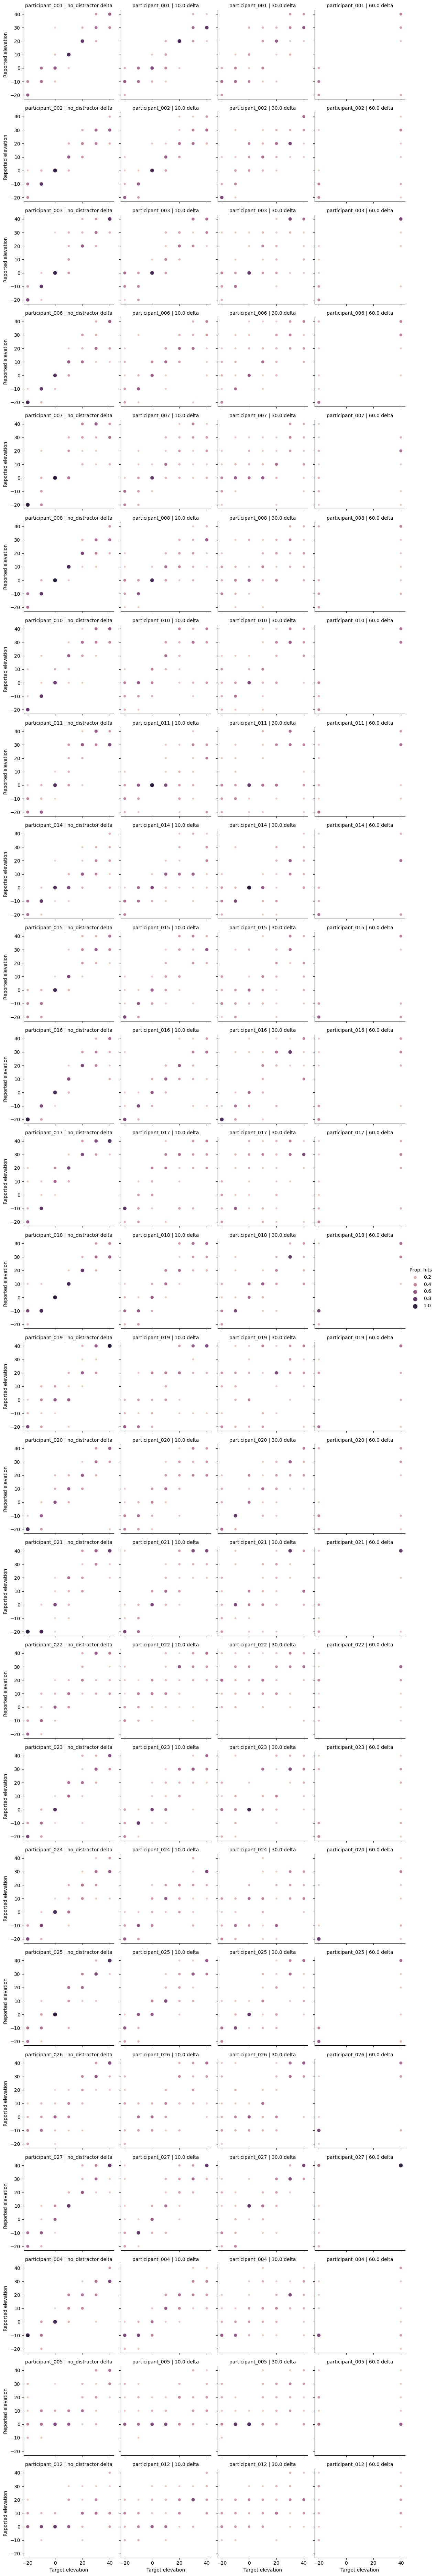

In [8]:
to_plot = results_df[(results_df.target_azimuth==0) & (results_df.azim_delta.isin([0, 'no_distractor']))].copy()
to_plot = to_plot.groupby(['target_azimuth', 'target_elevation', 'distractor_cond', 'pred_elevation', 'elev_delta', 'part_id']).count().reset_index()

for true_elev in to_plot.target_elevation.unique():
    for dist_cond in to_plot.elev_delta.unique():
        for part_id in to_plot.part_id.unique():
            elev_cond_ix = (to_plot.target_elevation == true_elev) & (to_plot.elev_delta == dist_cond) & (to_plot.part_id == part_id)
            elev_cond_trials = to_plot[elev_cond_ix]
            total_trials = elev_cond_trials.response.sum()
            to_plot.loc[elev_cond_ix, 'prop_hits'] = elev_cond_trials['response'].div(total_trials)

fig_dim = 5
# fig, axs = plt.subplots(figsize=(fig_dim,fig_dim))

g = sns.relplot(kind='scatter', data=to_plot, x='target_elevation', y='pred_elevation',
                     hue='prop_hits', size='prop_hits',
                     col='elev_delta',
                    row='part_id',

                     height=3, aspect=1,
                    #  sizes=(5,20),
                    #  hue_norm=(.1, .5),
                    )
g.set_titles("{row_name} | {col_name} delta")
g.legend.set_title('Prop. hits')
g.set(xlabel='Target elevation', ylabel='Reported elevation')




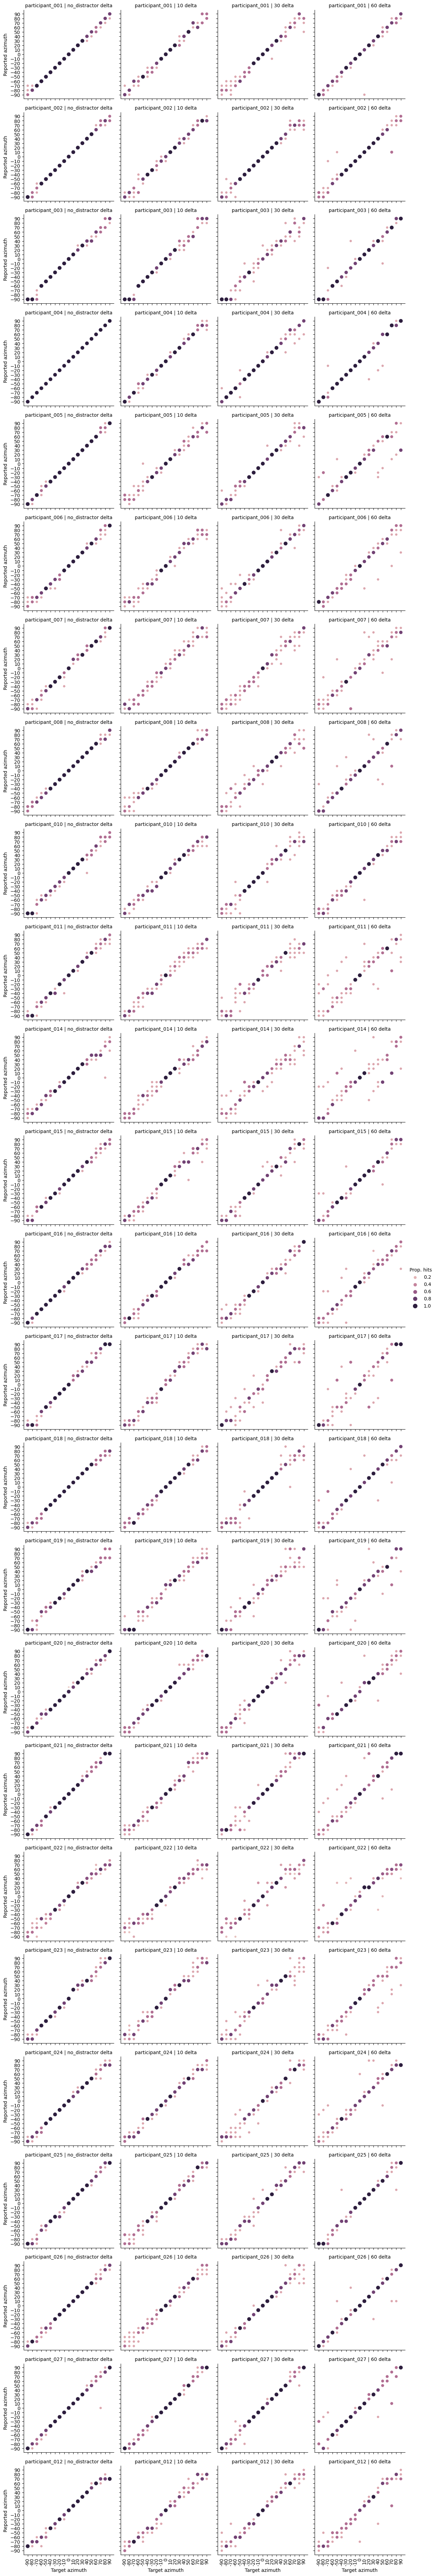

In [9]:
to_plot = results_df[(results_df.target_elevation ==0) & (results_df.elev_delta.isin([0, 'no_distractor']))].copy()
to_plot = to_plot.groupby(['target_azimuth', 'target_elevation', 'distractor_cond', 'pred_azimuth', 'azim_delta', 'part_id']).count().reset_index()

for true_elev in to_plot.target_azimuth.unique():
    for dist_cond in to_plot.azim_delta.unique():
        for part_id in to_plot.part_id.unique():
            azim_cond_ix = (to_plot.target_azimuth == true_elev) & (to_plot.azim_delta == dist_cond) & (to_plot.part_id == part_id)
            azim_cond_trials = to_plot[azim_cond_ix]
            total_trials = azim_cond_trials.response.sum()
            to_plot.loc[azim_cond_ix, 'prop_hits'] = azim_cond_trials['response'].div(total_trials)


fig_dim = 5
# fig, axs = plt.subplots(figsize=(fig_dim,fig_dim))

g = sns.relplot(kind='scatter', data=to_plot, x='target_azimuth', y='pred_azimuth',
                     hue='prop_hits', size='prop_hits',
                     col='azim_delta',
                     row='part_id',
                     height=3,
                    #  sizes=(5,20),
                    #  hue_norm=(.1, .5),
                    )
g.legend.set_title('Prop. hits')
g.set_titles("{row_name} | {col_name} delta")
g.set(xlabel='Target azimuth', ylabel='Reported azimuth', xticks=np.arange(-90, 91, 10), yticks=np.arange(-90, 91, 10))
g.set_xticklabels(labels=np.arange(-90, 91, 10), rotation=90)




In [10]:
### Get mean absolute error 
results_df['azim_error'] =  np.abs(results_df['target_azimuth'] - results_df['pred_azimuth'])
results_df['elev_error'] =  np.abs(results_df['target_elevation'] - results_df['pred_elevation']) 

In [11]:
# remove bias per participant per elevation
for part_id in results_df.part_id.unique():
    for elev in results_df.target_elevation.unique():
        elev_ix = (results_df.part_id == part_id) & (results_df.target_elevation == elev) & (results_df.distractor_cond == 'no distractor') & (results_df.target_azimuth == 0)
        all_elev_trial_ixs = (results_df.part_id == part_id) & (results_df.target_elevation == elev)  & (results_df.target_azimuth == 0)
        # get participant elevation bias
        elev_bias = results_df.loc[elev_ix, 'pred_elevation'].mean() 
        results_df.loc[all_elev_trial_ixs, 'error_rel_elev_resp_bias'] = np.abs(results_df.loc[all_elev_trial_ixs, 'pred_elevation'] - elev_bias)
        # print(part_id, elev, elev_bias)

    # same for azimuth 
    for azim in results_df.target_azimuth.unique():
        azim_ix = (results_df.part_id == part_id) & (results_df.target_azimuth == azim) & (results_df.distractor_cond == 'no distractor') & (results_df.target_elevation == 0)
        all_azim_trial_ixs = (results_df.part_id == part_id) & (results_df.target_azimuth == azim)  & (results_df.target_elevation == 0)
        # get participant azimuth bias, defined as their average error in the no distractor condition
        azim_bias =  results_df.loc[azim_ix, 'pred_azimuth'].mean()
        # print(part_id, azim, azim_bias)
        results_df.loc[all_azim_trial_ixs, 'error_rel_azim_resp_bias'] = np.abs(results_df.loc[all_azim_trial_ixs, 'pred_azimuth'] - azim_bias)

In [12]:
### Summarize azim and elev relative errors based on trial case 
elev_delta_trials = (results_df.elev_delta != 0) & (results_df.target_azimuth == 0) 
results_df.loc[elev_delta_trials, 'trial_plane'] = 'Elevation'
results_df.loc[elev_delta_trials, 'error_rel_resp_bias'] = results_df.loc[elev_delta_trials, 'error_rel_elev_resp_bias']


azim_delta_trials = (results_df.azim_delta != 0) & (results_df.target_elevation == 0)
results_df.loc[azim_delta_trials, 'trial_plane'] = 'Azimuth'
results_df.loc[azim_delta_trials, 'error_rel_resp_bias'] = results_df.loc[azim_delta_trials, 'error_rel_azim_resp_bias']
results_df.head()


,trial_num,locations,response,target_loc,distractor_loc,azim_delta,elev_delta,snr,target_speaker_label,distractor_speaker_label,...,Unnamed: 0,gt_info,true_loc,distractor_cond,azim_error,elev_error,error_rel_elev_resp_bias,error_rel_azim_resp_bias,trial_plane,error_rel_resp_bias
0,17,"[[[0, 0], [0, 0]]]",e10,"(0, 0)",None,no_distractor,no_distractor,0,E10,None,...,NaN,NaN,NaN,no distractor,0,0,2.142857,0.0,Azimuth,0.0
1,18,"[[[0, 0], [-80, 0]]]",e2,"(-80, 0)","(-50, 0)",30,0.0,0,E2,E5,...,NaN,NaN,NaN,with distractor,0,0,NaN,2.5,Azimuth,2.5
2,19,"[[[0, 0], [-90, 0]]]",e3,"(-90, 0)","(-60, 0)",30,0.0,0,E1,E4,...,NaN,NaN,NaN,with distractor,20,0,NaN,12.5,Azimuth,12.5
3,20,"[[[0, 0], [-90, 0]]]",e2,"(-90, 0)","(-60, 0)",30,0.0,0,E1,E4,...,NaN,NaN,NaN,with distractor,10,0,NaN,2.5,Azimuth,2.5
4,21,"[[[0, 0], [0, 0]]]",e10,"(0, 0)",None,no_distractor,no_distractor,0,E10,None,...,NaN,NaN,NaN,no distractor,0,0,2.142857,0.0,Azimuth,0.0


In [13]:
## Group by participant 

by_participant_summary_df = results_df.groupby(['part_id', 'distractor_cond', 'target_azimuth', 'target_elevation', 'azim_delta', 'elev_delta', 'sex_cond', 'trial_plane']).agg({'azim_error': 'mean',
                                                                                                                                       'elev_error': 'mean',
                                                                                                                                    #    'error_rel_elev_resp_bias':'mean',
                                                                                                                                    #    'error_rel_azim_resp_bias':'mean',
                                                                                                                                       'error_rel_resp_bias': 'mean'}).reset_index()

by_participant_summary_df['elev_delta'] = by_participant_summary_df['elev_delta'].astype('category')
by_participant_summary_df['azim_delta'] = by_participant_summary_df['azim_delta'].astype('category')

by_participant_summary_df['elev_delta'] = [int(delta) if delta != 'no_distractor' else delta for delta in by_participant_summary_df['elev_delta']]

by_participant_summary_df.loc[by_participant_summary_df['trial_plane'] == 'Elevation', 'dist_offset'] = by_participant_summary_df.loc[by_participant_summary_df['trial_plane'] == 'Elevation', 'elev_delta']
by_participant_summary_df.loc[by_participant_summary_df['trial_plane'] == 'Azimuth', 'dist_offset'] = by_participant_summary_df.loc[by_participant_summary_df['trial_plane'] == 'Azimuth', 'azim_delta']

# flatten columns
# by_participant_summary_df.columns = ['_'.join(col).strip() for col in by_participant_summary_df.columns.values]
# # remve _ in the end of each column name
# by_participant_summary_df.columns = [col[:-1] if col[-1] == '_' else col for col in by_participant_summary_df.columns]
by_participant_summary_df.head()

,part_id,distractor_cond,target_azimuth,target_elevation,azim_delta,elev_delta,sex_cond,trial_plane,azim_error,elev_error,error_rel_resp_bias,dist_offset
0,participant_001,no distractor,-90,0,no_distractor,no_distractor,different,Azimuth,7.500000,0.0,7.500000,no_distractor
1,participant_001,no distractor,-80,0,no_distractor,no_distractor,different,Azimuth,3.333333,0.0,4.166667,no_distractor
2,participant_001,no distractor,-80,0,no_distractor,no_distractor,same,Azimuth,0.000000,0.0,2.500000,no_distractor
3,participant_001,no distractor,-70,0,no_distractor,no_distractor,different,Azimuth,0.000000,0.0,0.000000,no_distractor
4,participant_001,no distractor,-70,0,no_distractor,no_distractor,same,Azimuth,0.000000,0.0,0.000000,no_distractor


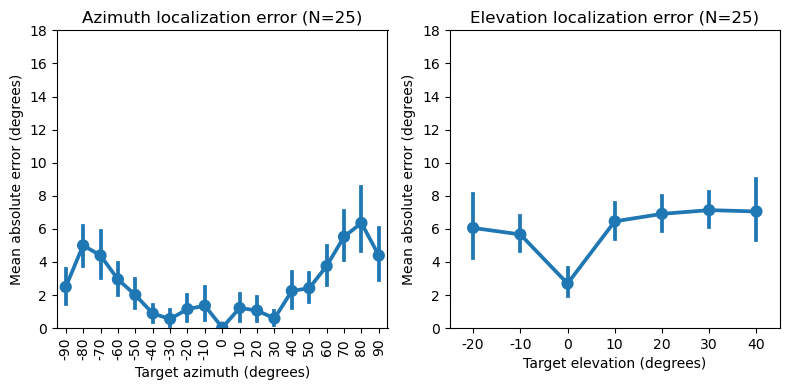

In [14]:
## Plot mean abs localization error
fig, axs = plt.subplots(1, 2, figsize=(8, 4))
to_plot = by_participant_summary_df[(by_participant_summary_df.elev_delta.isin(['no_distractor'])) & (by_participant_summary_df.azim_delta.isin(['no_distractor']))].copy()
N = to_plot.part_id.nunique()
sns.pointplot(data=to_plot[to_plot.target_elevation == 0], x='target_azimuth', y='azim_error', ax=axs[0])
sns.pointplot(data=to_plot[to_plot.target_azimuth == 0], x='target_elevation', y='elev_error', ax=axs[1])
axs[0].set_ylabel('Mean absolute error (degrees)')
axs[1].set_ylabel('Mean absolute error (degrees)')
axs[0].set_xlabel('Target azimuth (degrees)')
axs[0].set_xticklabels(labels=np.arange(-90, 91, 10), rotation=90)
axs[1].set_xlabel('Target elevation (degrees)')

axs[0].set_title(f'Azimuth localization error (N={N})')
axs[1].set_title(f'Elevation localization error (N={N})')


for ax in axs:
    ax.set_ylim(0, 18)
plt.tight_layout()


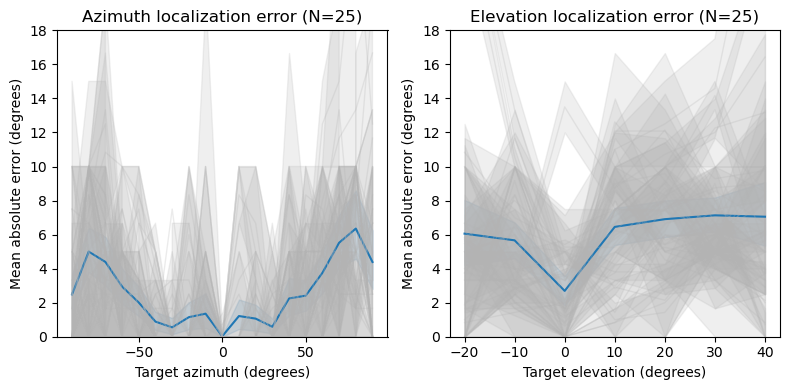

In [15]:
## Plot mean abs localization error
fig, axs = plt.subplots(1, 2, figsize=(8, 4))
to_plot = by_participant_summary_df[(by_participant_summary_df.elev_delta.isin(['no_distractor'])) & (by_participant_summary_df.azim_delta.isin(['no_distractor']))].copy()
N = to_plot.part_id.nunique()
sns.lineplot(data=to_plot[to_plot.target_elevation == 0], x='target_azimuth', y='azim_error', ax=axs[0])
sns.lineplot(data=to_plot[to_plot.target_azimuth == 0], x='target_elevation', y='elev_error', ax=axs[1])
axs[0].set_ylabel('Mean absolute error (degrees)')
axs[1].set_ylabel('Mean absolute error (degrees)')
axs[0].set_xlabel('Target azimuth (degrees)')
# axs[0].set_xticklabels(labels=np.arange(-90, 91, 10), rotation=90)
axs[1].set_xlabel('Target elevation (degrees)')

axs[0].set_title(f'Azimuth localization error (N={N})')
axs[1].set_title(f'Elevation localization error (N={N})')

# plot individual participants behind each main plot 
for part_id in to_plot.part_id.unique():
    part_data = to_plot[to_plot.part_id == part_id]
    sns.lineplot(data=part_data[part_data.target_elevation==0], x='target_azimuth', y='azim_error', ax=axs[0],  color=".7", linewidth=1, alpha=0.25)
    sns.lineplot(data=part_data[part_data.target_azimuth==0], x='target_elevation', y='elev_error', ax=axs[1],  color=".7", linewidth=1, alpha=0.25)

for ax in axs:
    ax.set_ylim(0, 18)
plt.tight_layout()


In [16]:
by_participant_summary_df.head()

,part_id,distractor_cond,target_azimuth,target_elevation,azim_delta,elev_delta,sex_cond,trial_plane,azim_error,elev_error,error_rel_resp_bias,dist_offset
0,participant_001,no distractor,-90,0,no_distractor,no_distractor,different,Azimuth,7.500000,0.0,7.500000,no_distractor
1,participant_001,no distractor,-80,0,no_distractor,no_distractor,different,Azimuth,3.333333,0.0,4.166667,no_distractor
2,participant_001,no distractor,-80,0,no_distractor,no_distractor,same,Azimuth,0.000000,0.0,2.500000,no_distractor
3,participant_001,no distractor,-70,0,no_distractor,no_distractor,different,Azimuth,0.000000,0.0,0.000000,no_distractor
4,participant_001,no distractor,-70,0,no_distractor,no_distractor,same,Azimuth,0.000000,0.0,0.000000,no_distractor


In [17]:
#### Get full summary df 

summary_df = by_participant_summary_df.groupby(['part_id', 'dist_offset', 'sex_cond', 'trial_plane']).agg({'error_rel_resp_bias': 'mean'}).reset_index()

In [18]:

def summarize_for_offset_analysis(df, conditions_to_group):
    summary = df.groupby(['part_id', 'distractor_cond', 'target_azimuth', 'target_elevation', 'azim_delta', 'elev_delta', 'sex_cond', 'trial_plane']).agg({'error_rel_resp_bias': 'mean'}).reset_index()
    summary['elev_delta'] = summary['elev_delta'].astype('category')
    summary['azim_delta'] = summary['azim_delta'].astype('category')
    summary['elev_delta'] = [int(delta) if delta != 'no_distractor' else delta for delta in summary['elev_delta']]
    summary.loc[summary['trial_plane'] == 'Elevation', 'dist_offset'] = summary.loc[summary['trial_plane'] == 'Elevation', 'elev_delta']
    summary.loc[summary['trial_plane'] == 'Azimuth', 'dist_offset'] = summary.loc[summary['trial_plane'] == 'Azimuth', 'azim_delta']
    summary = summary.groupby(conditions_to_group).agg({'error_rel_resp_bias': 'mean'}).reset_index()
    return summary 

Text(0.5, 1.05, 'All participants (N=25)')

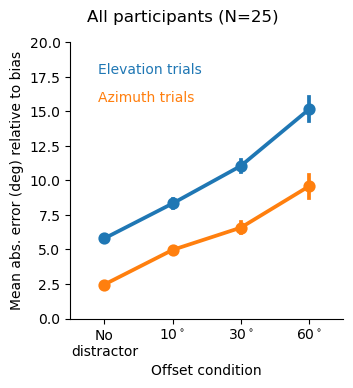

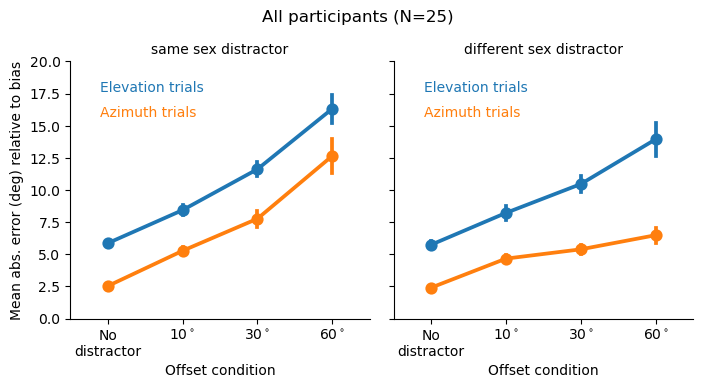

In [19]:
### Same plot but using grouped data 


order = ['no_distractor', 10, 30, 60]
hue_order = ['Elevation', 'Azimuth']
N = summary_df.part_id.nunique()
g = sns.catplot(data=summary_df,
            order=order,    
            x='dist_offset', y='error_rel_resp_bias',
            # col='sex_cond', col_order=['same', 'different'],
            hue='trial_plane', hue_order=hue_order,   
            #  col='part_id',
            errorbar='se',# errstyle='bars', col
            legend=False,
            kind='point', height=3.5, aspect=1)

g.set_titles("{col_name} sex distractor")
g.set(xlabel='Offset condition', ylabel='Mean abs. error (deg) relative to bias', )
# g.legend().remove()
# add legend with correct colors

## Add text to indicate conditions
for ax in g.axes.flatten():
    ax.text(0.1, 0.9, 'Elevation trials', horizontalalignment='left', verticalalignment='center', transform=ax.transAxes, color='tab:blue')
    ax.text(0.1, 0.8, 'Azimuth trials', horizontalalignment='left', verticalalignment='center', transform=ax.transAxes, color='tab:orange')
    ax.set_xticklabels(['No\ndistractor', '10$^\circ$', '30$^\circ$', '60$^\circ$'])
    ax.set_ylim(0,20)
plt.suptitle(f"All participants (N={N})", y=1.05)
# g.ax.text(0.1, 0.9, 'Elevation trials', horizontalalignment='left', verticalalignment='center', transform=g.ax.transAxes, color='tab:blue')
# g.ax.text(0.1, 0.8, 'Azimuth trials', horizontalalignment='left', verticalalignment='center', transform=g.ax.transAxes, color='tab:orange')

# update xticks
# plt.title(f'N={N}')

g = sns.catplot(data=summary_df,
            order=order,    
            x='dist_offset', y='error_rel_resp_bias',
            col='sex_cond', col_order=['same', 'different'],
            hue='trial_plane', hue_order=hue_order,   
            #  col='part_id',
            errorbar='se',# errstyle='bars', col
            legend=False,
            kind='point', height=3.5, aspect=1)

g.set_titles("{col_name} sex distractor")
g.set(xlabel='Offset condition', ylabel='Mean abs. error (deg) relative to bias', )
# g.legend().remove()
# add legend with correct colors

## Add text to indicate conditions
for ax in g.axes.flatten():
    ax.text(0.1, 0.9, 'Elevation trials', horizontalalignment='left', verticalalignment='center', transform=ax.transAxes, color='tab:blue')
    ax.text(0.1, 0.8, 'Azimuth trials', horizontalalignment='left', verticalalignment='center', transform=ax.transAxes, color='tab:orange')
    ax.set_xticklabels(['No\ndistractor', '10$^\circ$', '30$^\circ$', '60$^\circ$'])
    ax.set_ylim(0,20)
plt.suptitle(f"All participants (N={N})", y=1.05)


In [20]:
summary_df

,part_id,dist_offset,sex_cond,trial_plane,error_rel_resp_bias
0,participant_001,10,different,Azimuth,4.534314
1,participant_001,10,different,Elevation,6.068027
2,participant_001,10,same,Azimuth,4.861111
3,participant_001,10,same,Elevation,5.618594
4,participant_001,30,different,Azimuth,5.277778
...,...,...,...,...,...
395,participant_027,60,same,Elevation,15.000000
396,participant_027,no_distractor,different,Azimuth,2.258772
397,participant_027,no_distractor,different,Elevation,4.950794
398,participant_027,no_distractor,same,Azimuth,3.645833


###

In [21]:
# ### Run repeated measures anova on different sex trials 

import statsmodels.api as sm
from statsmodels.stats.anova import AnovaRM


ModuleNotFoundError: No module named 'statsmodels'

In [22]:

anova_fit = AnovaRM(summary_df, 'error_rel_resp_bias', 'part_id', within=['dist_offset', 'trial_plane', 'sex_cond']).fit()
print(anova_fit.anova_table)
[f"{val:.4f}" for val in anova_fit.anova_table['Pr > F'].values ]

                                    F Value  Num DF  Den DF        Pr > F
dist_offset                       86.563484     3.0    57.0  3.298984e-21
trial_plane                       88.678387     1.0    19.0  1.372812e-08
sex_cond                          16.554283     1.0    19.0  6.549304e-04
dist_offset:trial_plane            1.954712     3.0    57.0  1.310719e-01
dist_offset:sex_cond              10.310479     3.0    57.0  1.606825e-05
trial_plane:sex_cond               4.274303     1.0    19.0  5.258897e-02
dist_offset:trial_plane:sex_cond   1.443979     3.0    57.0  2.395275e-01


['0.0000', '0.0000', '0.0007', '0.1311', '0.0000', '0.0526', '0.2395']

## Filter participants based on mean absolute localization error 

Exclude participants who's mean absolute localization error on single-talkers is greater than the minimum distance between two speakers in the array

In [22]:

def summarize_for_offset_analysis(df, conditions_to_group):
    summary = df.groupby(['part_id', 'distractor_cond', 'target_azimuth', 'target_elevation', 'azim_delta', 'elev_delta', 'sex_cond', 'trial_plane']).agg({'error_rel_resp_bias': 'mean'}).reset_index()
    summary['elev_delta'] = summary['elev_delta'].astype('category')
    summary['azim_delta'] = summary['azim_delta'].astype('category')
    summary['elev_delta'] = [int(delta) if delta != 'no_distractor' else delta for delta in summary['elev_delta']]
    summary.loc[summary['trial_plane'] == 'Elevation', 'dist_offset'] = summary.loc[summary['trial_plane'] == 'Elevation', 'elev_delta']
    summary.loc[summary['trial_plane'] == 'Azimuth', 'dist_offset'] = summary.loc[summary['trial_plane'] == 'Azimuth', 'azim_delta']
    summary = summary.groupby(conditions_to_group).agg({'error_rel_resp_bias': 'mean'}).reset_index()
    return summary 

#### Work out minimum error

If we take guessing as choosing between the target speaker or the two adjacent speakers next to it, we can work out a chance mean absolute error. The absolute distance between the target and either of the two speakers is 10 degrees. If guessing between the target and either adjacent speaker we have have error rates of 0 or 10 (the sample space). Assuming no bias per location, the chance performance is the expectation over guessing, i.e. the average $(10 - 0) / 2$

In [23]:
np.random.seed(0)

criterion = 5 # guessing is (10 degrees - 0 degrees) / 2 ie. assuming a guess is between the target and two adjacent speakers, the absolute error is 10 degrees, the minimum spacing between any two speakers in the array 
no_distractor = results_df[results_df.distractor_cond == 'no distractor'].copy()
no_distractor['abs_target_azim'] = np.abs(no_distractor['target_azimuth'])
# sample_for_inclusion = no_distractor.groupby(['part_id','target_azimuth', 'target_elevation']).sample(frac=0.5)
sample_for_inclusion = no_distractor.groupby(['part_id','abs_target_azim', 'target_elevation']).sample(n=5) # 5 is half the number of elevation trials 
# track trials used to determine inclusion, to exclude from analysis 
trials_to_exclude = sample_for_inclusion.index.values
part_err = {}
for part in sample_for_inclusion.part_id.unique():
    part_data = sample_for_inclusion[sample_for_inclusion.part_id == part]
    # max mean abs error in azim and elev 
    azim_mean_abs_err = part_data[part_data.target_elevation == 0].groupby('target_azimuth').agg({'azim_error': 'mean'}).mean().item()
    elev_mean_abs_err = part_data[part_data.target_azimuth == 0].groupby('target_elevation').agg({'elev_error': 'mean'}).mean().item()
    mean_mae =  np.mean([azim_mean_abs_err, elev_mean_abs_err])
    # mean_mae = part_data[['azim_error', 'elev_error']].values.flatten().mean() # np.mean([azim_mean_abs_err, elev_mean_abs_err])

    max_abs_err = max(elev_mean_abs_err, azim_mean_abs_err) 

    part_err[part] = {'azim_error': azim_mean_abs_err , 'elev_error':elev_mean_abs_err, 'max_abs_err': max_abs_err, "mean_mae": mean_mae}
    
# part_err
screen_df = pd.DataFrame.from_records([(k,v['azim_error'], v['elev_error'], v['max_abs_err'], v['mean_mae']) for k,v in part_err.items()], columns=['part_id', 'mean_abs_err', 'mean_elev_err', 'max_abs_err', 'mean_mae'])
screen_df

,part_id,mean_abs_err,mean_elev_err,max_abs_err,mean_mae
0,participant_001,1.842105,3.428571,3.428571,2.635338
1,participant_002,0.789474,4.571429,4.571429,2.680451
2,participant_003,3.070175,5.142857,5.142857,4.106516
3,participant_004,0.000000,6.000000,6.000000,3.000000
4,participant_005,0.833333,12.571429,12.571429,6.702381
5,participant_006,2.894737,5.142857,5.142857,4.018797
6,participant_007,3.245614,6.285714,6.285714,4.765664
7,participant_008,1.491228,3.428571,3.428571,2.459900
8,participant_010,3.464912,5.428571,5.428571,4.446742
9,participant_011,4.210526,6.571429,6.571429,5.390977


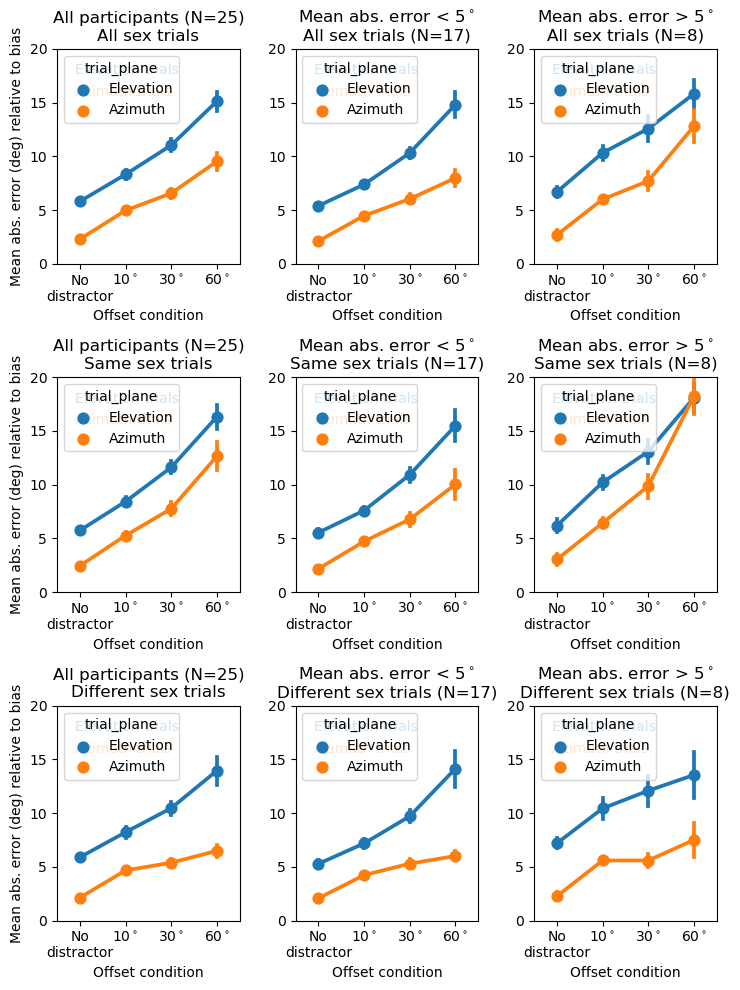

In [24]:
fig, axs = plt.subplots(3, 3, figsize=((2.5 * 3), 10))

to_plot = results_df[~results_df.index.isin(trials_to_exclude)].copy()

error_size = [0, 5, 5]
sex_conds = ['all', 'same', 'different']
for ix, error_deg in enumerate(error_size): 

    if ix == 1:
        good_participants = screen_df[screen_df.mean_mae < error_deg].part_id
    elif ix == 2:
        good_participants = screen_df[screen_df.mean_mae > error_deg].part_id
    else:
        good_participants = screen_df.part_id
    
    to_analyze = to_plot[to_plot.part_id.isin(good_participants)].copy()
    N = len(good_participants)
    # resummarize per participant, excluding trials used to determine inclusion 
    to_plot_sex_summary = summarize_for_offset_analysis(to_analyze, ['part_id', 'dist_offset', 'sex_cond', 'trial_plane'])
    to_plot_total_summary = summarize_for_offset_analysis(to_analyze, ['part_id', 'dist_offset', 'trial_plane'])
    
    order = ['no_distractor', 10, 30, 60]
    for jx, sex_cond in enumerate(sex_conds):
        ax = axs[jx, ix]
        if jx == 0:
            group_to_plot = to_plot_total_summary
        else:
            group_to_plot = to_plot_sex_summary[to_plot_sex_summary.sex_cond == sex_cond]
            
        sns.pointplot(data=group_to_plot,
                    order=order,    
                    x='dist_offset', y='error_rel_resp_bias',
                    hue='trial_plane', hue_order=hue_order,   
                    # legend=False,
                    errorbar='se',#
                    ax=ax)
        if ix == 0:
            ax.set_ylabel('Mean abs. error (deg) relative to bias')
        else:
            ax.set_ylabel('')
        ax.set(xlabel='Offset condition')
        # g.legend().remove()
        # add legend with correct colors

        ## Add text to indicate conditions
        ax.text(0.1, 0.9, 'Elevation trials', horizontalalignment='left', verticalalignment='center', transform=ax.transAxes, color='tab:blue')
        ax.text(0.1, 0.8, 'Azimuth trials', horizontalalignment='left', verticalalignment='center', transform=ax.transAxes, color='tab:orange')

        # update xticks
        ax.set_xticklabels(['No\ndistractor', '10$^\circ$', '30$^\circ$', '60$^\circ$'])
        if ix == 0:
            ax.set_title(f'All participants (N={N})\n{sex_cond.title()} sex trials')
        elif ix == 1:
            ax.set_title(f'Mean abs. error < {error_deg}$^\circ$\n{sex_cond.title()} sex trials (N={N})')
        elif ix == 2:
            ax.set_title(f'Mean abs. error > {error_deg}$^\circ$\n{sex_cond.title()} sex trials (N={N})')
        ax.set_ylim(0,20)

plt.tight_layout()

### Run stats on trials 

TypeError: pointplot() got an unexpected keyword argument 'legend'

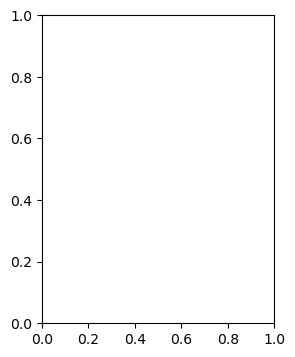

In [25]:
### Run ANOVA for good participants (above 25th percentile)
for_anova = results_df[~results_df.index.isin(trials_to_exclude)].copy()


good_participants = screen_df[screen_df.mean_mae < 5].part_id
for_anova = for_anova[for_anova.part_id.isin(good_participants)]

# summarize for anova 
for_anova_avg_sex_conds = summarize_for_offset_analysis(for_anova, ['part_id', 'dist_offset', 'trial_plane'])
for_anova_sex_conds = summarize_for_offset_analysis(for_anova, ['part_id', 'dist_offset', 'trial_plane', 'sex_cond'])


N = for_anova.part_id.nunique()
### Plot data for anova 

fig, axs = plt.subplots(1, figsize=(3, 4))

sns.pointplot(data=for_anova_avg_sex_conds,
            order=order,    
            x='dist_offset', y='error_rel_resp_bias',
            hue='trial_plane', hue_order=hue_order,   
            legend=False,
            errorbar='se',
            ax=axs)
axs.set_title(f"All trials using\nscreened participants (N={N})", y=1.05)

# sns.pointplot(data=for_anova_sex_conds[for_anova_sex_conds.sex_cond == 'different'],
#             order=order,    
#             x='dist_offset', y='error_rel_resp_bias',
#             hue='trial_plane', hue_order=hue_order,   
#             legend=False,
#             errorbar='se',
#             ax=axs)

# axs.set_title(f"Different sex trials using\n all participants (N={N})", y=1.05)

for ix, ax in enumerate([axs]):
    # ax = a
        # if ix == 0:
    ax.set_ylabel('Mean abs. error (deg) relative to bias')
        # else:
        #     ax.set_ylabel('')
    ax.set(xlabel='Offset condition')
    # g.legend().remove()
    # add legend with correct colors

    ## Add text to indicate conditions
    ax.text(0.1, 0.9, 'Elevation trials', horizontalalignment='left', verticalalignment='center', transform=ax.transAxes, color='tab:blue')
    ax.text(0.1, 0.8, 'Azimuth trials', horizontalalignment='left', verticalalignment='center', transform=ax.transAxes, color='tab:orange')

    # update xticks
    ax.set_xticklabels(['No\ndistractor', '10$^\circ$', '30$^\circ$', '60$^\circ$'])
    ax.set_ylim(0,20)
# plt.suptitle(f"Screenig: Acc. > {ptile_cutoff*100:.0f}% (N={N})")
plt.tight_layout()


# anova_fit = AnovaRM(for_anova_sex_conds[for_anova_sex_conds.sex_cond == 'different'], 'error_rel_resp_bias', 'part_id', within=['dist_offset', 'trial_plane']).fit()
# print("ANOVA diff sex cond only:")
# print(anova_fit.anova_table)
# print([f"{val:.4f}" for val in anova_fit.anova_table['Pr > F'].values ])


anova_fit = AnovaRM(for_anova_avg_sex_conds, 'error_rel_resp_bias', 'part_id', within=['dist_offset', 'trial_plane']).fit()
print("ANOVA averaging over sex cond:")
print(anova_fit.anova_table)
[f"{val:.4f}" for val in anova_fit.anova_table['Pr > F'].values ]


TypeError: pointplot() got an unexpected keyword argument 'legend'

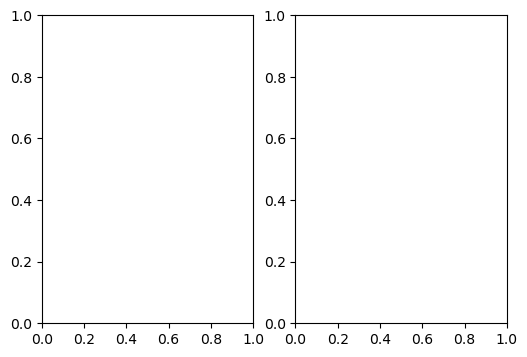

In [26]:
### Run ANOVA for good participants (above 25th percentile)
for_anova = results_df[~results_df.index.isin(trials_to_exclude)].copy()


good_participants = screen_df[screen_df.mean_mae < 5].part_id
for_anova = for_anova[for_anova.part_id.isin(good_participants)]

# summarize for anova 
for_anova_avg_sex_conds = summarize_for_offset_analysis(for_anova, ['part_id', 'dist_offset', 'trial_plane'])
for_anova_sex_conds = summarize_for_offset_analysis(for_anova, ['part_id', 'dist_offset', 'trial_plane', 'sex_cond'])


N = for_anova.part_id.nunique()
### Plot data for anova 

fig, axs = plt.subplots(1,2, figsize=(6, 4))

sns.pointplot(data=for_anova_avg_sex_conds,
            order=order,    
            x='dist_offset', y='error_rel_resp_bias',
            hue='trial_plane', hue_order=hue_order,   
            legend=False,
            errorbar='se',
            ax=axs[0])
axs[0].set_title(f"All trials using\nscreened participants (N={N})", y=1.05)

sns.pointplot(data=for_anova_sex_conds[for_anova_sex_conds.sex_cond == 'different'],
            order=order,    
            x='dist_offset', y='error_rel_resp_bias',
            hue='trial_plane', hue_order=hue_order,   
            legend=False,
            errorbar='se',
            ax=axs[1])

axs[1].set_title(f"Different sex trials using\nscreened participants (N={N})", y=1.05)

for ix, ax in enumerate(axs):
    # ax = a
        # if ix == 0:
    ax.set_ylabel('Mean abs. error (deg) relative to bias')
        # else:
        #     ax.set_ylabel('')
    ax.set(xlabel='Offset condition')
    # g.legend().remove()
    # add legend with correct colors

    ## Add text to indicate conditions
    ax.text(0.1, 0.9, 'Elevation trials', horizontalalignment='left', verticalalignment='center', transform=ax.transAxes, color='tab:blue')
    ax.text(0.1, 0.8, 'Azimuth trials', horizontalalignment='left', verticalalignment='center', transform=ax.transAxes, color='tab:orange')

    # update xticks
    ax.set_xticklabels(['No\ndistractor', '10$^\circ$', '30$^\circ$', '60$^\circ$'])
    ax.set_ylim(0,20)
# plt.suptitle(f"Screenig: Acc. > {ptile_cutoff*100:.0f}% (N={N})")
plt.tight_layout()

anova_fit = AnovaRM(for_anova_avg_sex_conds, 'error_rel_resp_bias', 'part_id', within=['dist_offset', 'trial_plane']).fit()
print("ANOVA avg. over sex cond:")
print(anova_fit.anova_table)
print([f"{val:.4f}" for val in anova_fit.anova_table['Pr > F'].values ])
print("\n")


anova_fit = AnovaRM(for_anova_sex_conds[for_anova_sex_conds.sex_cond == 'different'], 'error_rel_resp_bias', 'part_id', within=['dist_offset', 'trial_plane']).fit()
print("ANOVA diff sex cond only:")
print(anova_fit.anova_table)
print([f"{val:.4f}" for val in anova_fit.anova_table['Pr > F'].values ])




## Compute includion using only target locations in main study

In [27]:
results_df.target_azimuth.unique(
    
)

array([  0, -80, -90, -70, -10,  60,  50, -20, -60, -30, -50,  90,  80,
        10,  30,  70,  20,  40, -40])

In [28]:
np.random.seed(0)

criterion = 5 # guessing is (10 degrees - 0 degrees) / 2 ie. assuming a guess is between the target and two adjacent speakers, the absolute error is 10 degrees, the minimum spacing between any two speakers in the array 
no_distractor = results_df[(results_df.distractor_cond == 'no distractor') & (results_df.target_elevation.isin([0, -20, 40])) & (results_df.target_azimuth.isin([0, 90, -90]))].copy()
no_distractor['abs_target_azim'] = np.abs(no_distractor['target_azimuth'])
sample_for_inclusion = no_distractor.groupby(['part_id','abs_target_azim', 'target_elevation']).sample(n=5)


# track trials used to determine inclusion, to exclude from analysis 
trials_to_exclude = sample_for_inclusion.index.values
part_err = {}
for part in sample_for_inclusion.part_id.unique():
    part_data = sample_for_inclusion[sample_for_inclusion.part_id == part]
    # max mean abs error in azim and elev 
    azim_mean_abs_err = part_data[part_data.target_elevation == 0].groupby('target_azimuth').agg({'azim_error': 'mean'}).mean().item()
    elev_mean_abs_err = part_data[part_data.target_azimuth == 0].groupby('target_elevation').agg({'elev_error': 'mean'}).mean().item()
    mean_mae =  np.mean([azim_mean_abs_err, elev_mean_abs_err])
    # mean_mae = part_data[['azim_error', 'elev_error']].values.flatten().mean() # np.mean([azim_mean_abs_err, elev_mean_abs_err])

    max_abs_err = max(elev_mean_abs_err, azim_mean_abs_err) 

    part_err[part] = {'azim_error': azim_mean_abs_err , 'elev_error':elev_mean_abs_err, 'max_abs_err': max_abs_err, "mean_mae": mean_mae}
    
# part_err
screen_df = pd.DataFrame.from_records([(k, v['azim_error'], v['elev_error'], v['max_abs_err'], v['mean_mae']) for k,v in part_err.items()], columns=['part_id', 'mean_azim_err', 'mean_elev_err', 'max_abs_err', 'mean_mae'])
screen_df

,part_id,mean_azim_err,mean_elev_err,max_abs_err,mean_mae
0,participant_001,3.888889,4.666667,4.666667,4.277778
1,participant_002,1.666667,6.000000,6.000000,3.833333
2,participant_003,1.111111,1.333333,1.333333,1.222222
3,participant_004,0.000000,6.666667,6.666667,3.333333
4,participant_005,0.000000,11.333333,11.333333,5.666667
5,participant_006,2.222222,4.000000,4.000000,3.111111
6,participant_007,0.000000,6.000000,6.000000,3.000000
7,participant_008,2.777778,4.000000,4.000000,3.388889
8,participant_010,2.222222,4.666667,4.666667,3.444444
9,participant_011,5.833333,5.333333,5.833333,5.583333


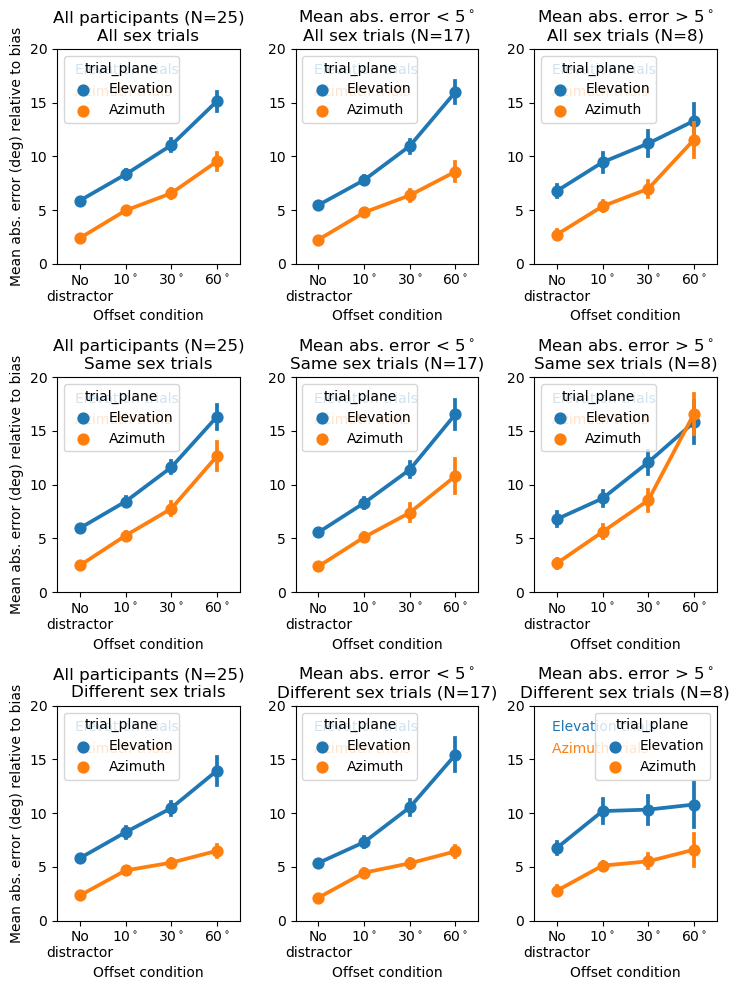

In [29]:
fig, axs = plt.subplots(3, 3, figsize=((2.5 * 3), 10))

to_plot = results_df[~results_df.index.isin(trials_to_exclude)].copy()

error_size = [0, 5, 5]
sex_conds = ['all', 'same', 'different']
for ix, error_deg in enumerate(error_size): 

    if ix == 1:
        good_participants = screen_df[screen_df.mean_mae < error_deg].part_id
    elif ix == 2:
        good_participants = screen_df[screen_df.mean_mae > error_deg].part_id
    else:
        good_participants = screen_df.part_id
    
    to_analyze = to_plot[to_plot.part_id.isin(good_participants)].copy()
    N = len(good_participants)
    # resummarize per participant, excluding trials used to determine inclusion 
    to_plot_sex_summary = summarize_for_offset_analysis(to_analyze, ['part_id', 'dist_offset', 'sex_cond', 'trial_plane'])
    to_plot_total_summary = summarize_for_offset_analysis(to_analyze, ['part_id', 'dist_offset', 'trial_plane'])
    
    order = ['no_distractor', 10, 30, 60]
    for jx, sex_cond in enumerate(sex_conds):
        ax = axs[jx, ix]
        if jx == 0:
            group_to_plot = to_plot_total_summary
        else:
            group_to_plot = to_plot_sex_summary[to_plot_sex_summary.sex_cond == sex_cond]
            
        sns.pointplot(data=group_to_plot,
                    order=order,    
                    x='dist_offset', y='error_rel_resp_bias',
                    hue='trial_plane', hue_order=hue_order,   
                    # legend=False,
                    errorbar='se',#
                    ax=ax)
        if ix == 0:
            ax.set_ylabel('Mean abs. error (deg) relative to bias')
        else:
            ax.set_ylabel('')
        ax.set(xlabel='Offset condition')
        # g.legend().remove()
        # add legend with correct colors

        ## Add text to indicate conditions
        ax.text(0.1, 0.9, 'Elevation trials', horizontalalignment='left', verticalalignment='center', transform=ax.transAxes, color='tab:blue')
        ax.text(0.1, 0.8, 'Azimuth trials', horizontalalignment='left', verticalalignment='center', transform=ax.transAxes, color='tab:orange')

        # update xticks
        ax.set_xticklabels(['No\ndistractor', '10$^\circ$', '30$^\circ$', '60$^\circ$'])
        if ix == 0:
            ax.set_title(f'All participants (N={N})\n{sex_cond.title()} sex trials')
        elif ix == 1:
            ax.set_title(f'Mean abs. error < {error_deg}$^\circ$\n{sex_cond.title()} sex trials (N={N})')
        elif ix == 2:
            ax.set_title(f'Mean abs. error > {error_deg}$^\circ$\n{sex_cond.title()} sex trials (N={N})')
        ax.set_ylim(0,20)

plt.tight_layout()

ANOVA diff sex cond only:
                            F Value  Num DF  Den DF        Pr > F
dist_offset               36.169233     3.0    39.0  2.380347e-11
trial_plane              102.869901     1.0    13.0  1.526490e-07
dist_offset:trial_plane    7.122870     3.0    39.0  6.285181e-04
['0.0000', '0.0000', '0.0006']
ANOVA without sex cond:
                            F Value  Num DF  Den DF        Pr > F
dist_offset               58.989272     3.0    39.0  1.478859e-14
trial_plane              149.335215     1.0    13.0  1.679613e-08
dist_offset:trial_plane    6.451206     3.0    39.0  1.184292e-03


/tmp/ipykernel_3094331/585699912.py:53: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['No\ndistractor', '10$^\circ$', '30$^\circ$', '60$^\circ$'])


['0.0000', '0.0000', '0.0012']

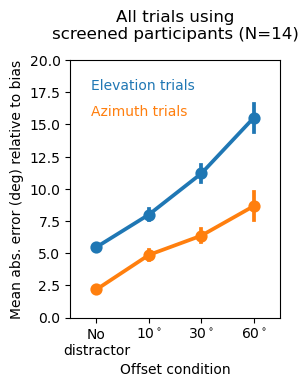

In [55]:
### Run ANOVA for good participants (above 25th percentile)
for_anova = results_df[~results_df.index.isin(trials_to_exclude)].copy()


good_participants = screen_df[screen_df.mean_mae < 5].part_id
for_anova = for_anova[for_anova.part_id.isin(good_participants)]

# summarize for anova 
for_anova_avg_sex_conds = summarize_for_offset_analysis(for_anova, ['part_id', 'dist_offset', 'trial_plane'])
for_anova_sex_conds = summarize_for_offset_analysis(for_anova, ['part_id', 'dist_offset', 'trial_plane', 'sex_cond'])


N = for_anova.part_id.nunique()
### Plot data for anova 

fig, axs = plt.subplots(1, figsize=(3, 4))

sns.pointplot(data=for_anova_avg_sex_conds,
            order=order,    
            x='dist_offset', y='error_rel_resp_bias',
            hue='trial_plane', hue_order=hue_order,   
            legend=False,
            errorbar='se',
            ax=axs)
# axs[0].set_title(f"All trials using\nscreened participants (N={N})", y=1.05)
axs.set_title(f"All trials using\nscreened participants (N={N})", y=1.05)

# sns.pointplot(data=for_anova_sex_conds[for_anova_sex_conds.sex_cond == 'different'],
#             order=order,    
#             x='dist_offset', y='error_rel_resp_bias',
#             hue='trial_plane', hue_order=hue_order,   
#             legend=False,
#             errorbar='se',
#             ax=axs[1])

# axs[1].set_title(f"Different sex trials using\nscreened participants (N={N})", y=1.05)

for ix, ax in enumerate([axs]):
    # ax = a
        # if ix == 0:
    ax.set_ylabel('Mean abs. error (deg) relative to bias')
        # else:
        #     ax.set_ylabel('')
    ax.set(xlabel='Offset condition')
    # g.legend().remove()
    # add legend with correct colors

    ## Add text to indicate conditions
    ax.text(0.1, 0.9, 'Elevation trials', horizontalalignment='left', verticalalignment='center', transform=ax.transAxes, color='tab:blue')
    ax.text(0.1, 0.8, 'Azimuth trials', horizontalalignment='left', verticalalignment='center', transform=ax.transAxes, color='tab:orange')

    # update xticks
    ax.set_xticklabels(['No\ndistractor', '10$^\circ$', '30$^\circ$', '60$^\circ$'])
    ax.set_ylim(0,20)
# plt.suptitle(f"Screenig: Acc. > {ptile_cutoff*100:.0f}% (N={N})")
plt.tight_layout()


anova_fit = AnovaRM(for_anova_sex_conds[for_anova_sex_conds.sex_cond == 'different'], 'error_rel_resp_bias', 'part_id', within=['dist_offset', 'trial_plane']).fit()
print("ANOVA diff sex cond only:")
print(anova_fit.anova_table)
print([f"{val:.4f}" for val in anova_fit.anova_table['Pr > F'].values ])


anova_fit = AnovaRM(for_anova_avg_sex_conds, 'error_rel_resp_bias', 'part_id', within=['dist_offset', 'trial_plane']).fit()
print("ANOVA without sex cond:")
print(anova_fit.anova_table)
[f"{val:.4f}" for val in anova_fit.anova_table['Pr > F'].values ]


## Filter participants based on accuracy
Old method - only here for reference  

In [52]:
np.random.seed(0)

results_df['accuracy'] = (results_df['response'].str.upper() == results_df['target_speaker_label']).astype('int')

no_distractor = results_df[results_df.distractor_cond == 'no distractor'].copy()
# use first half of trials to get participant accuracy
# part_acc_dict = {}
# trials_to_exclude = []

sample_for_acc = no_distractor.groupby('part_id').sample(frac=0.5)
acc_par_part = sample_for_acc.groupby('part_id').accuracy.mean()
trials_to_exclude = sample_for_acc.index.values


# for part_id in no_distractor.part_id.unique():
#     part_total_trials = 0 
#     part_running_acc = 0 
#     part_trials = no_distractor[no_distractor.part_id == part_id]
#     n_trials_per_location = part_trials["target_speaker_label"].value_counts()
#     for location, n_trials in n_trials_per_location.items():
#         trials_for_acc = part_trials[part_trials["target_speaker_label"] == location].head(n_trials)
#         trials_to_exclude.append(trials_for_acc.index.values)
#         part_total_trials += n_trials
#         part_running_acc += trials_for_acc.accuracy.sum()
#     part_acc_dict[part_id] = part_running_acc / part_total_trials

# trials_to_exclude = np.concatenate(trials_to_exclude)


/tmp/ipykernel_1718822/2838367230.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['No\ndistractor', '10$^\circ$', '30$^\circ$', '60$^\circ$'])
/tmp/ipykernel_1718822/2838367230.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['No\ndistractor', '10$^\circ$', '30$^\circ$', '60$^\circ$'])
/tmp/ipykernel_1718822/2838367230.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['No\ndistractor', '10$^\circ$', '30$^\circ$', '60$^\circ$'])
/tmp/ipykernel_1718822/2838367230.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['No\ndistractor', '10$^\circ$', '30$^\circ$', '60$^\c

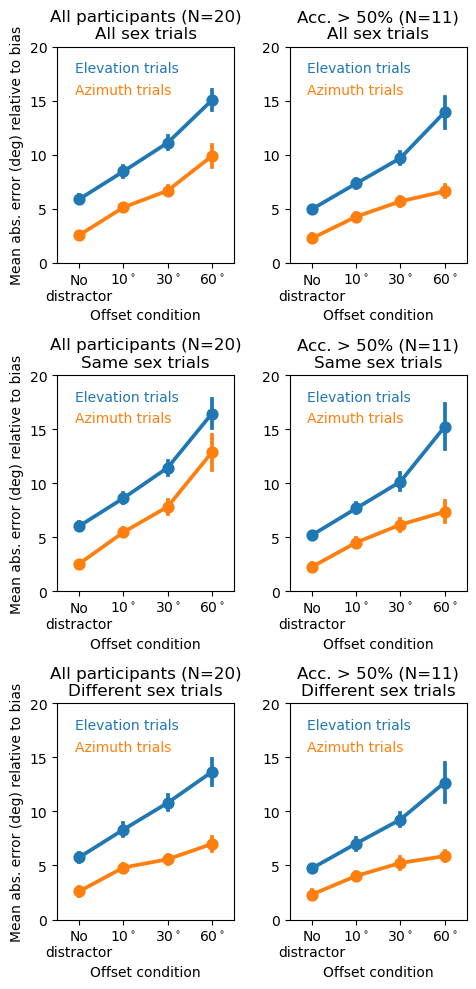

In [93]:

to_plot = results_df[~results_df.index.isin(trials_to_exclude)].copy()

acc_values = [0, .5 ]
fig, axs = plt.subplots(3, len(acc_values), figsize=(5 , 10))


sex_conds = ['all', 'same', 'different']
for ix, ptile_cutoff in enumerate(acc_values): 
    if ix > 0:
        # ptile_cutoff = np.percentile(acc_par_part.values, ptile_value)
        good_participants = acc_par_part[acc_par_part >= ptile_cutoff].index
    else:
        good_participants = acc_par_part.index
    
    to_analyze = to_plot[to_plot.part_id.isin(good_participants)].copy()
    N = len(good_participants)
    # resummarize per participant, excluding trials used to determine inclusion 
    to_plot_sex_summary = summarize_for_offset_analysis(to_analyze, ['part_id', 'dist_offset', 'sex_cond', 'trial_plane'])
    to_plot_total_summary = summarize_for_offset_analysis(to_analyze, ['part_id', 'dist_offset', 'trial_plane'])
    
    order = ['no_distractor', 10, 30, 60]
    for jx, sex_cond in enumerate(sex_conds):
        ax = axs[jx, ix]
        if jx == 0:
            group_to_plot = to_plot_total_summary
        else:
            group_to_plot = to_plot_sex_summary[to_plot_sex_summary.sex_cond == sex_cond]
            
        sns.pointplot(data=group_to_plot,
                    order=order,    
                    x='dist_offset', y='error_rel_resp_bias',
                    hue='trial_plane', hue_order=hue_order,   
                    legend=False,
                    errorbar='se',#
                    ax=ax)
        if ix == 0:
            ax.set_ylabel('Mean abs. error (deg) relative to bias')
        else:
            ax.set_ylabel('')
        ax.set(xlabel='Offset condition')
        # g.legend().remove()
        # add legend with correct colors

        ## Add text to indicate conditions
        ax.text(0.1, 0.9, 'Elevation trials', horizontalalignment='left', verticalalignment='center', transform=ax.transAxes, color='tab:blue')
        ax.text(0.1, 0.8, 'Azimuth trials', horizontalalignment='left', verticalalignment='center', transform=ax.transAxes, color='tab:orange')

        # update xticks
        ax.set_xticklabels(['No\ndistractor', '10$^\circ$', '30$^\circ$', '60$^\circ$'])
        if ix == 0:
            ax.set_title(f'All participants (N={N})\n{sex_cond.title()} sex trials')
        else:
            ax.set_title(f'Acc. > {ptile_cutoff*100:.0f}% (N={N})\n{sex_cond.title()} sex trials')
        ax.set_ylim(0,20)

plt.tight_layout()

/tmp/ipykernel_1718822/3141222895.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['No\ndistractor', '10$^\circ$', '30$^\circ$', '60$^\circ$'])


ANOVA without sex cond:
                           F Value  Num DF  Den DF        Pr > F
dist_offset              51.052549     3.0    39.0  1.424076e-13
trial_plane              48.949148     1.0    13.0  9.391973e-06
dist_offset:trial_plane   3.172168     3.0    39.0  3.477220e-02


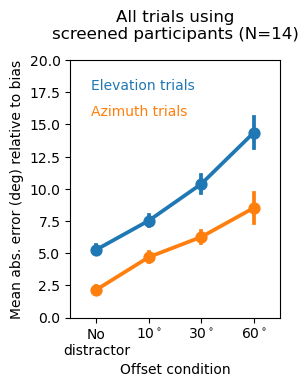

In [60]:
### Run ANOVA for good participants (above 25th percentile)
for_anova = results_df[~results_df.index.isin(trials_to_exclude)].copy()


ptile_cutoff = np.percentile(acc_par_part.values, 25)
good_participants = acc_par_part[acc_par_part > ptile_cutoff].index
for_anova = for_anova[for_anova.part_id.isin(good_participants)]

# summarize for anova 
for_anova_avg_sex_conds = summarize_for_offset_analysis(for_anova, ['part_id', 'dist_offset', 'trial_plane'])
for_anova_sex_conds = summarize_for_offset_analysis(for_anova, ['part_id', 'dist_offset', 'trial_plane', 'sex_cond'])


N = for_anova.part_id.nunique()
### Plot data for anova 

fig, axs = plt.subplots(1, figsize=(3, 4))

sns.pointplot(data=for_anova_avg_sex_conds,
            order=order,    
            x='dist_offset', y='error_rel_resp_bias',
            hue='trial_plane', hue_order=hue_order,   
            legend=False,
            errorbar='se',
            ax=axs)

axs.set_title(f"All trials using\nscreened participants (N={N})", y=1.05)

# for ix, ax in enumerate(axs):
ax = axs
    # if ix == 0:
ax.set_ylabel('Mean abs. error (deg) relative to bias')
    # else:
    #     ax.set_ylabel('')
ax.set(xlabel='Offset condition')
# g.legend().remove()
# add legend with correct colors

## Add text to indicate conditions
ax.text(0.1, 0.9, 'Elevation trials', horizontalalignment='left', verticalalignment='center', transform=ax.transAxes, color='tab:blue')
ax.text(0.1, 0.8, 'Azimuth trials', horizontalalignment='left', verticalalignment='center', transform=ax.transAxes, color='tab:orange')

# update xticks
ax.set_xticklabels(['No\ndistractor', '10$^\circ$', '30$^\circ$', '60$^\circ$'])
ax.set_ylim(0,20)
# plt.suptitle(f"Screenig: Acc. > {ptile_cutoff*100:.0f}% (N={N})")
plt.tight_layout()

# anova_fit = AnovaRM(for_anova_sex_conds, 'error_rel_resp_bias', 'part_id', within=['dist_offset', 'trial_plane', 'sex_cond']).fit()
# print("ANOVA with sex cond:")
# print(anova_fit.anova_table)

anova_fit = AnovaRM(for_anova_avg_sex_conds, 'error_rel_resp_bias', 'part_id', within=['dist_offset', 'trial_plane']).fit()
print("ANOVA without sex cond:")
print(anova_fit.anova_table)
# [f"{val:.4f}" for val in anova_fit.anova_table['Pr > F'].values ]


/tmp/ipykernel_1718822/608326426.py:45: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['No\ndistractor', '10$^\circ$', '30$^\circ$', '60$^\circ$'])


ANOVA without sex cond:
                           F Value  Num DF  Den DF        Pr > F
dist_offset              51.052549     3.0    39.0  1.424076e-13
trial_plane              48.949148     1.0    13.0  9.391973e-06
dist_offset:trial_plane   3.172168     3.0    39.0  3.477220e-02


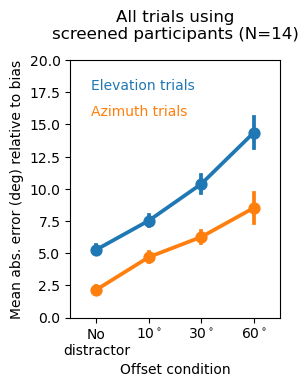

In [63]:
### Run ANOVA for good participants (above 25th percentile)
for_anova = results_df[~results_df.index.isin(trials_to_exclude)].copy()


ptile_cutoff = np.percentile(acc_par_part.values, 25)
good_participants = acc_par_part[acc_par_part > ptile_cutoff].index
for_anova = for_anova[for_anova.part_id.isin(good_participants)]

# summarize for anova 
for_anova_avg_sex_conds = summarize_for_offset_analysis(for_anova, ['part_id', 'dist_offset', 'trial_plane'])
for_anova_sex_conds = summarize_for_offset_analysis(for_anova, ['part_id', 'dist_offset', 'trial_plane', 'sex_cond'])


N = for_anova.part_id.nunique()
### Plot data for anova 

fig, axs = plt.subplots(1, figsize=(3, 4))

sns.pointplot(data=for_anova_avg_sex_conds,
            order=order,    
            x='dist_offset', y='error_rel_resp_bias',
            hue='trial_plane', hue_order=hue_order,   
            legend=False,
            errorbar='se',
            ax=axs)

axs.set_title(f"All trials using\nscreened participants (N={N})", y=1.05)


# for ix, ax in enumerate(axs):
ax = axs
    # if ix == 0:
ax.set_ylabel('Mean abs. error (deg) relative to bias')
    # else:
    #     ax.set_ylabel('')
ax.set(xlabel='Offset condition')
# g.legend().remove()
# add legend with correct colors

## Add text to indicate conditions
ax.text(0.1, 0.9, 'Elevation trials', horizontalalignment='left', verticalalignment='center', transform=ax.transAxes, color='tab:blue')
ax.text(0.1, 0.8, 'Azimuth trials', horizontalalignment='left', verticalalignment='center', transform=ax.transAxes, color='tab:orange')

# update xticks
ax.set_xticklabels(['No\ndistractor', '10$^\circ$', '30$^\circ$', '60$^\circ$'])
ax.set_ylim(0,20)
# plt.suptitle(f"Screenig: Acc. > {ptile_cutoff*100:.0f}% (N={N})")
plt.tight_layout()

# anova_fit = AnovaRM(for_anova_sex_conds, 'error_rel_resp_bias', 'part_id', within=['dist_offset', 'trial_plane', 'sex_cond']).fit()
# print("ANOVA with sex cond:")
# print(anova_fit.anova_table)

anova_fit = AnovaRM(for_anova_avg_sex_conds, 'error_rel_resp_bias', 'part_id', within=['dist_offset', 'trial_plane']).fit()
print("ANOVA without sex cond:")
print(anova_fit.anova_table)
# [f"{val:.4f}" for val in anova_fit.anova_table['Pr > F'].values ]


In [62]:
anova_fit = AnovaRM(for_anova_sex_conds[for_anova_sex_conds.sex_cond=='different'], 'error_rel_resp_bias', 'part_id', within=['dist_offset', 'trial_plane']).fit()
print("ANOVA with sex cond:")
print(anova_fit.anova_table)
[f"{val:.4f}" for val in anova_fit.anova_table['Pr > F'].values ]


ANOVA with sex cond:
                           F Value  Num DF  Den DF        Pr > F
dist_offset              27.676395     3.0    39.0  9.261475e-10
trial_plane              46.227642     1.0    13.0  1.264222e-05
dist_offset:trial_plane   3.700199     3.0    39.0  1.952751e-02


['0.0000', '0.0000', '0.0195']

### Old plot for ref, don't re-run 

[Text(0, 0, 'No distractor'),
 Text(1, 0, '10$^\\circ$'),
 Text(2, 0, '30$^\\circ$'),
 Text(3, 0, '60$^\\circ$')]

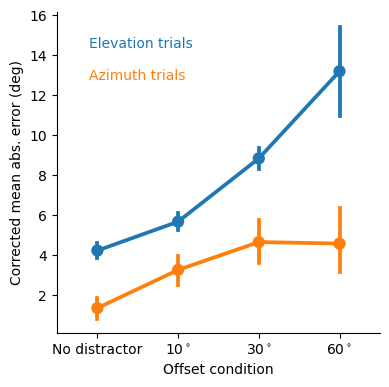

In [56]:
### Plot the error in azimuth and elevation
elev_to_plot = summary_df[(summary_df.target_azimuth == 0) & (summary_df.elev_delta!=0) ]
azim_to_plot = summary_df[(summary_df.target_elevation == 0) & (summary_df.azim_delta!=0) ]

g = sns.catplot(data=elev_to_plot,
             x='elev_delta', y='scaled_elev_error_mean',
            #  col='part_id',
             errorbar='se',# errstyle='bars', col
              kind='point', height=4, aspect=1)
sns.pointplot(data=azim_to_plot,
             x='azim_delta', y='scaled_azim_error_mean',
             color='tab:orange',
             ax=g.ax)
g.set(xlabel='Offset condition', ylabel='Corrected mean abs. error (deg)')
# g.legend().remove()
# add legend with correct colors

## Add text to indicate conditions
g.ax.text(0.1, 0.9, 'Elevation trials', horizontalalignment='left', verticalalignment='center', transform=g.ax.transAxes, color='tab:blue')
g.ax.text(0.1, 0.8, 'Azimuth trials', horizontalalignment='left', verticalalignment='center', transform=g.ax.transAxes, color='tab:orange')

# update xticks
g.ax.set_xticklabels(['No distractor', '10$^\circ$', '30$^\circ$', '60$^\circ$'])



[Text(0.5, 25.722222222222214, 'Azimuth difference'),
 Text(510.3244949494949, 0.5, 'Corrected mean abs. error (deg)'),
 (-1.0, 20.0)]

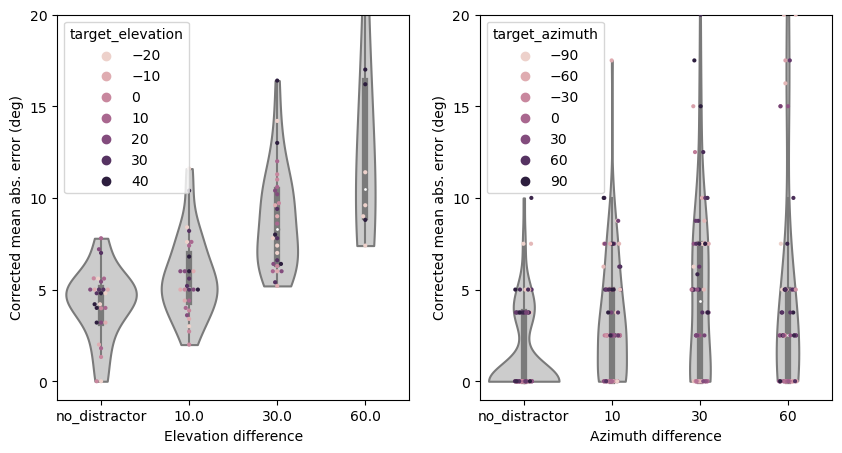

In [14]:
elev_to_plot = summary_df[(summary_df.target_azimuth == 0) & (summary_df.elev_delta!=0) ]
azim_to_plot = summary_df[(summary_df.target_elevation == 0) & (summary_df.azim_delta!=0) ]

fig, axs = plt.subplots(1, 2, figsize=(10, 5))

g = sns.violinplot(data=elev_to_plot, x="elev_delta", y="scaled_elev_error_mean", color = '0.8', cut=0, height=4, ax=axs[0])
sns.swarmplot(data=elev_to_plot, x="elev_delta", y="scaled_elev_error_mean", hue="target_elevation", size=3, ax=axs[0])

g.set(xlabel='Elevation difference', ylabel='Corrected mean abs. error (deg)', yticks=np.arange(0, 21, 5), ylim=(-1, 20))
# axs[0].legend().remove() # set_title('Elevation difference')



g = sns.violinplot(data=azim_to_plot, x="azim_delta", y="scaled_azim_error_mean", color = '0.8',  cut=0, height=4, ax=axs[1])
sns.stripplot(data=azim_to_plot, x="azim_delta", y="scaled_azim_error_mean", hue="target_azimuth", size=3, ax=axs[1])
g.set(xlabel='Azimuth difference', ylabel='Corrected mean abs. error (deg)', yticks=np.arange(0, 21, 5), ylim=(-1, 20))
# axs[1].legend().remove() # set_title('azimation difference')